In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid, save_image
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

OUTPUT_DIR = "/content/drive/MyDrive/outputs_a2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Device: cuda


In [3]:
def load_cifar10_horses():
    train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
    test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)

    def extract(ds):
        data = ds.data.astype(np.float32) / 255.0
        targets = np.array(ds.targets)
        idx = np.where(targets == 7)[0]
        data = data[idx]
        rgb = data.transpose(0, 3, 1, 2)
        grey = np.mean(rgb, axis=1, keepdims=True)
        return rgb, grey

    train_rgb, train_grey = extract(train)
    test_rgb, test_grey = extract(test)

    perm = np.random.permutation(train_rgb.shape[0])
    train_rgb = train_rgb[perm]
    train_grey = train_grey[perm]

    return (train_rgb, train_grey), (test_rgb, test_grey)

(train_rgb, train_grey), (test_rgb, test_grey) = load_cifar10_horses()
print("Train horses:", train_rgb.shape, train_grey.shape)
print("Test horses:", test_rgb.shape, test_grey.shape)

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Train horses: (5000, 3, 32, 32) (5000, 1, 32, 32)
Test horses: (1000, 3, 32, 32) (1000, 1, 32, 32)


In [19]:
from google.colab import files
uploaded = files.upload()
COLOUR_PATH = list(uploaded.keys())[0]

print("Using file:", COLOUR_PATH)
print("Exists:", os.path.exists(COLOUR_PATH))

def get_rgb_cat(xs, colours, batch_size=100):
    num = xs.shape[0]
    out = np.zeros((num, 1, xs.shape[2], xs.shape[3]), dtype=np.int64)
    for i in range(0, num, batch_size):
        batch = xs[i:i + batch_size]
        b = np.expand_dims(batch, 1)
        c = colours.reshape(1, colours.shape[0], 3, 1, 1)
        dists = np.linalg.norm(b - c, axis=2)
        cat = np.argmin(dists, axis=1)
        out[i:i + batch_size, 0] = cat
    return out

def get_cat_rgb(cats, colours):
    return colours[cats]

Saving colour_kmeans24_cat7.npy to colour_kmeans24_cat7 (2).npy
Using file: colour_kmeans24_cat7 (2).npy
Exists: True


In [21]:
def load_colours(path=COLOUR_PATH):
    data = np.load(path, allow_pickle=True, encoding="latin1")

    # If the file stores objects, pick the array that looks like color centers.
    if isinstance(data, np.ndarray) and data.dtype == object:
        candidates = [x for x in data.flat if isinstance(x, np.ndarray)]
        if not candidates:
            raise ValueError("No array found inside the object container.")
        # Pick the first array with last-dim 3 (RGB)
        colours = None
        for arr in candidates:
            if arr.ndim >= 2 and arr.shape[-1] == 3:
                colours = arr
                break
        if colours is None:
            colours = candidates[0]
    else:
        colours = data

    if colours.ndim == 3:
        colours = colours[0]

    return colours.astype(np.float32)

In [5]:
class RegressionDataset(Dataset):
    def __init__(self, grey, rgb):
        self.grey = torch.from_numpy(grey).float()
        self.rgb = torch.from_numpy(rgb).float()

    def __len__(self):
        return self.grey.shape[0]

    def __getitem__(self, idx):
        return self.grey[idx], self.rgb[idx]

class ClassificationDataset(Dataset):
    def __init__(self, grey, cats):
        self.grey = torch.from_numpy(grey).float()
        self.cats = torch.from_numpy(cats).long()

    def __len__(self):
        return self.grey.shape[0]

    def __getitem__(self, idx):
        return self.grey[idx], self.cats[idx, 0]

In [6]:
class RegressionCNN(nn.Module):
    def __init__(self, num_filters=32):
        super().__init__()
        self.downconv1 = nn.Sequential(
            nn.Conv2d(1, num_filters, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.downconv2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_filters * 2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.rfconv = nn.Sequential(
            nn.Conv2d(num_filters * 2, num_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_filters * 2),
            nn.ReLU()
        )
        self.upconv1 = nn.Sequential(
            nn.Conv2d(num_filters * 2, num_filters, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2)
        )
        self.upconv2 = nn.Sequential(
            nn.Conv2d(num_filters, 3, kernel_size=3, padding=1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Upsample(scale_factor=2)
        )
        self.finalconv = nn.Conv2d(3, 3, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.downconv1(x)
        out = self.downconv2(out)
        out = self.rfconv(out)
        out = self.upconv1(out)
        out = self.upconv2(out)
        out = self.finalconv(out)
        return out

class MyConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=None):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        if padding is None:
            self.padding = kernel_size // 2
        else:
            self.padding = padding
        self.weight = nn.Parameter(torch.Tensor(out_channels, in_channels, kernel_size, kernel_size))
        self.bias = nn.Parameter(torch.Tensor(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        n = self.in_channels * self.kernel_size * self.kernel_size
        stdv = 1.0 / np.sqrt(n)
        self.weight.data.uniform_(-stdv, stdv)
        self.bias.data.uniform_(-stdv, stdv)

    def forward(self, input):
        return F.conv2d(input, self.weight, self.bias, padding=self.padding)

class ClassificationCNN(nn.Module):
    def __init__(self, num_colours, num_filters=32):
        super().__init__()
        self.downconv1 = nn.Sequential(
            MyConv2d(1, num_filters, kernel_size=3),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.downconv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters * 2, kernel_size=3),
            nn.BatchNorm2d(num_filters * 2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.rfconv = nn.Sequential(
            MyConv2d(num_filters * 2, num_filters * 2, kernel_size=3),
            nn.BatchNorm2d(num_filters * 2),
            nn.ReLU()
        )
        self.upconv1 = nn.Sequential(
            MyConv2d(num_filters * 2, num_filters, kernel_size=3),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2)
        )
        self.upconv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters, kernel_size=3),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2)
        )
        self.finalconv = MyConv2d(num_filters, num_colours, kernel_size=1, padding=0)

    def forward(self, x):
        out = self.downconv1(x)
        out = self.downconv2(out)
        out = self.rfconv(out)
        out = self.upconv1(out)
        out = self.upconv2(out)
        out = self.finalconv(out)
        return out

class UNet(nn.Module):
    def __init__(self, num_colours, num_filters=32):
        super().__init__()
        self.down1 = nn.Sequential(
            MyConv2d(1, num_filters, kernel_size=3),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            MyConv2d(num_filters, num_filters, kernel_size=3),
            nn.BatchNorm2d(num_filters),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = nn.Sequential(
            MyConv2d(num_filters, num_filters * 2, kernel_size=3),
            nn.BatchNorm2d(num_filters * 2),
            nn.ReLU(),
            MyConv2d(num_filters * 2, num_filters * 2, kernel_size=3),
            nn.BatchNorm2d(num_filters * 2),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(
            MyConv2d(num_filters * 2, num_filters * 4, kernel_size=3),
            nn.BatchNorm2d(num_filters * 4),
            nn.ReLU()
        )
        self.up1 = nn.Upsample(scale_factor=2)
        self.up1_conv = nn.Sequential(
            MyConv2d(num_filters * 4 + num_filters * 2, num_filters * 2, kernel_size=3),
            nn.BatchNorm2d(num_filters * 2),
            nn.ReLU()
        )
        self.up2 = nn.Upsample(scale_factor=2)
        self.up2_conv = nn.Sequential(
            MyConv2d(num_filters * 2 + num_filters, num_filters, kernel_size=3),
            nn.BatchNorm2d(num_filters),
            nn.ReLU()
        )
        self.finalconv = MyConv2d(num_filters + 1, num_colours, kernel_size=1, padding=0)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        b = self.bottleneck(p2)
        u1 = self.up1(b)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.up1_conv(u1)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up2_conv(u2)
        u2 = torch.cat([u2, x], dim=1)
        out = self.finalconv(u2)
        return out

In [7]:
def save_regression_samples(model, grey, rgb, out_dir, tag):
    model.eval()
    with torch.no_grad():
        pred = model(grey.to(device)).cpu()
    pred = pred.clamp(0, 1)
    grey_vis = grey.repeat(1, 3, 1, 1)
    grid = torch.cat([grey_vis, pred, rgb], dim=0)
    save_image(grid, os.path.join(out_dir, f"{tag}_regression.png"), nrow=grey.size(0))

def save_classification_samples(model, grey, cats, colours, out_dir, tag):
    model.eval()
    with torch.no_grad():
        logits = model(grey.to(device)).cpu()
    pred_cats = torch.argmax(logits, dim=1).numpy()
    pred_rgb = colours[pred_cats]
    pred_rgb = torch.from_numpy(pred_rgb).permute(0, 3, 1, 2).float()
    gt_rgb = colours[cats.numpy()]
    gt_rgb = torch.from_numpy(gt_rgb).permute(0, 3, 1, 2).float()
    grey_vis = grey.repeat(1, 3, 1, 1)
    grid = torch.cat([grey_vis, pred_rgb, gt_rgb], dim=0)
    save_image(grid, os.path.join(out_dir, f"{tag}_classification.png"), nrow=grey.size(0))

def train_regression(model, loader, epochs, lr):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for grey, rgb in loader:
            grey = grey.to(device)
            rgb = rgb.to(device)
            pred = model(grey)
            loss = criterion(pred, rgb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item()
        avg = running / len(loader)
        history.append(avg)
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg:.4f}")
    return history

def train_classification(model, loader, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for grey, labels in loader:
            grey = grey.to(device)
            labels = labels.to(device)
            logits = model(grey)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item()
        avg = running / len(loader)
        history.append(avg)
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg:.4f}")
    return history

def eval_classification(model, loader):
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0.0
    correct = 0.0
    total = 0.0
    with torch.no_grad():
        for grey, labels in loader:
            grey = grey.to(device)
            labels = labels.to(device)
            logits = model(grey)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.numel()
    return total_loss / len(loader), 100.0 * correct / total

## Regression model training
training a regression CNN model to predict RGB values from grayscale input.

Epoch 1/10 - Loss: 0.1966
Epoch 2/10 - Loss: 0.0383
Epoch 3/10 - Loss: 0.0189
Epoch 4/10 - Loss: 0.0163
Epoch 5/10 - Loss: 0.0149
Epoch 6/10 - Loss: 0.0139
Epoch 7/10 - Loss: 0.0130
Epoch 8/10 - Loss: 0.0124
Epoch 9/10 - Loss: 0.0117
Epoch 10/10 - Loss: 0.0113


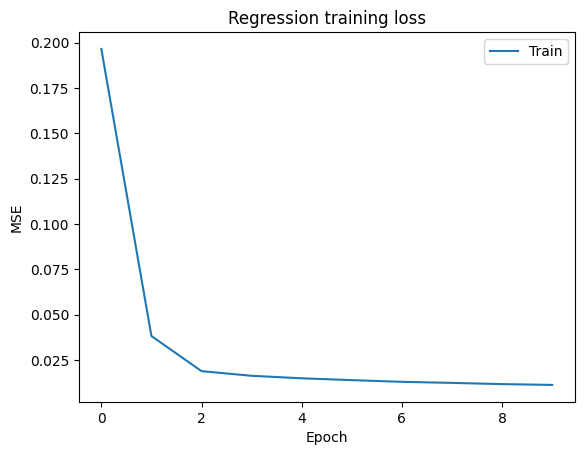

Saved regression samples to /content/drive/MyDrive/outputs_a2/regression
Saved regression loss plot to /content/drive/MyDrive/outputs_a2/regression/regression_loss.png


In [8]:
REG_EPOCHS = 10
REG_BATCH = 100
REG_LR = 1e-3

reg_train = RegressionDataset(train_grey, train_rgb)
reg_test = RegressionDataset(test_grey, test_rgb)
reg_train_loader = DataLoader(reg_train, batch_size=REG_BATCH, shuffle=True)
reg_test_loader = DataLoader(reg_test, batch_size=10, shuffle=False)

reg_model = RegressionCNN(num_filters=32)
reg_history = train_regression(reg_model, reg_train_loader, REG_EPOCHS, REG_LR)

reg_out_dir = os.path.join(OUTPUT_DIR, "regression")
os.makedirs(reg_out_dir, exist_ok=True)

plt.figure()
plt.plot(reg_history, label="Train")
plt.title("Regression training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
reg_plot_path = os.path.join(reg_out_dir, "regression_loss.png")
plt.savefig(reg_plot_path)
plt.show()

grey_batch, rgb_batch = next(iter(reg_test_loader))
save_regression_samples(reg_model, grey_batch, rgb_batch, reg_out_dir, tag="samples")
print("Saved regression samples to", reg_out_dir)
print("Saved regression loss plot to", reg_plot_path)

## Regression CNN layer table

In [9]:
def summarize_conv_layers(model):
    rows = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            k = module.kernel_size
            rows.append((name, f"{k[0]}x{k[1]}", module.out_channels))
    return rows

summary = summarize_conv_layers(reg_model)
print("Layer\tKernel\tFilters")
for name, k, c in summary:
    print(f"{name}\t{k}\t{c}")

Layer	Kernel	Filters
downconv1.0	3x3	32
downconv2.0	3x3	64
rfconv.0	3x3	64
upconv1.0	3x3	32
upconv2.0	3x3	3
finalconv	3x3	3


## Regression training variations

Epoch 1/5 - Loss: 0.1027
Epoch 2/5 - Loss: 0.0268
Epoch 3/5 - Loss: 0.0192
Epoch 4/5 - Loss: 0.0163
Epoch 5/5 - Loss: 0.0145
Epoch 1/10 - Loss: 0.1045
Epoch 2/10 - Loss: 0.0213
Epoch 3/10 - Loss: 0.0165
Epoch 4/10 - Loss: 0.0151
Epoch 5/10 - Loss: 0.0141
Epoch 6/10 - Loss: 0.0135
Epoch 7/10 - Loss: 0.0129
Epoch 8/10 - Loss: 0.0124
Epoch 9/10 - Loss: 0.0122
Epoch 10/10 - Loss: 0.0118
Epoch 1/20 - Loss: 0.1269
Epoch 2/20 - Loss: 0.0281
Epoch 3/20 - Loss: 0.0192
Epoch 4/20 - Loss: 0.0163
Epoch 5/20 - Loss: 0.0151
Epoch 6/20 - Loss: 0.0143
Epoch 7/20 - Loss: 0.0136
Epoch 8/20 - Loss: 0.0131
Epoch 9/20 - Loss: 0.0127
Epoch 10/20 - Loss: 0.0122
Epoch 11/20 - Loss: 0.0118
Epoch 12/20 - Loss: 0.0115
Epoch 13/20 - Loss: 0.0113
Epoch 14/20 - Loss: 0.0110
Epoch 15/20 - Loss: 0.0107
Epoch 16/20 - Loss: 0.0104
Epoch 17/20 - Loss: 0.0102
Epoch 18/20 - Loss: 0.0100
Epoch 19/20 - Loss: 0.0098
Epoch 20/20 - Loss: 0.0097


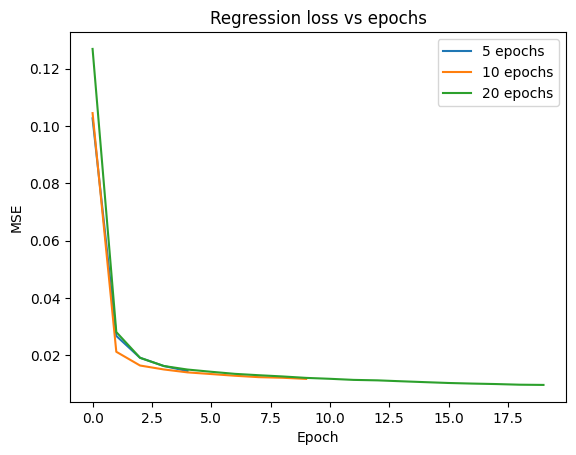

Saved regression variations plot to /content/drive/MyDrive/outputs_a2/regression/regression_variations.png


In [27]:
RUN_VARIANTS = True
EPOCH_VARIANTS = [5, 10, 20]

if RUN_VARIANTS:
    variant_histories = {}
    grey_batch, rgb_batch = next(iter(reg_test_loader))
    for epochs in EPOCH_VARIANTS:
        model = RegressionCNN(num_filters=32)
        history = train_regression(model, reg_train_loader, epochs, REG_LR)
        variant_histories[epochs] = history
        variant_dir = os.path.join(reg_out_dir, f"variant_{epochs}")
        os.makedirs(variant_dir, exist_ok=True)
        save_regression_samples(model, grey_batch, rgb_batch, variant_dir, tag="samples")

    plt.figure()
    for epochs, history in variant_histories.items():
        plt.plot(history, label=f"{epochs} epochs")
    plt.title("Regression loss vs epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    var_plot_path = os.path.join(reg_out_dir, "regression_variations.png")
    plt.savefig(var_plot_path)
    plt.show()
    print("Saved regression variations plot to", var_plot_path)

## Classification model training
treats colorization as pixel-wise classification over 24 colors.

In [23]:
colours = load_colours()
print("Colours shape:", colours.shape)

train_cats_cache = "./cache_train_cats.npy"
test_cats_cache = "./cache_test_cats.npy"

if os.path.exists(train_cats_cache) and os.path.exists(test_cats_cache):
    train_cats = np.load(train_cats_cache)
    test_cats = np.load(test_cats_cache)
else:
    train_cats = get_rgb_cat(train_rgb, colours)
    test_cats = get_rgb_cat(test_rgb, colours)
    np.save(train_cats_cache, train_cats)
    np.save(test_cats_cache, test_cats)

cls_train = ClassificationDataset(train_grey, train_cats)
cls_test = ClassificationDataset(test_grey, test_cats)
cls_train_loader = DataLoader(cls_train, batch_size=100, shuffle=True)
cls_test_loader = DataLoader(cls_test, batch_size=10, shuffle=False)

Colours shape: (24, 3)


Epoch 1/10 - Loss: 2.6865
Epoch 2/10 - Loss: 2.2998
Epoch 3/10 - Loss: 2.1261
Epoch 4/10 - Loss: 1.9993
Epoch 5/10 - Loss: 1.9551
Epoch 6/10 - Loss: 1.8900
Epoch 7/10 - Loss: 1.8613
Epoch 8/10 - Loss: 1.8462
Epoch 9/10 - Loss: 1.8226
Epoch 10/10 - Loss: 1.8061
Validation loss: 1.7850 | Validation acc: 36.67%


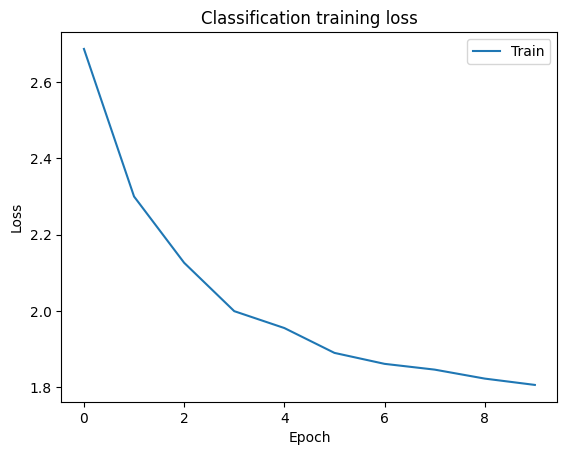

Saved classification samples to /content/drive/MyDrive/outputs_a2/classification
Saved classification loss plot to /content/drive/MyDrive/outputs_a2/classification/classification_loss.png


In [24]:
CLS_EPOCHS = 10
CLS_LR = 1e-3

cls_model = ClassificationCNN(num_colours=colours.shape[0], num_filters=32)
cls_history = train_classification(cls_model, cls_train_loader, CLS_EPOCHS, CLS_LR)
val_loss, val_acc = eval_classification(cls_model, cls_test_loader)
print(f"Validation loss: {val_loss:.4f} | Validation acc: {val_acc:.2f}%")

cls_out_dir = os.path.join(OUTPUT_DIR, "classification")
os.makedirs(cls_out_dir, exist_ok=True)

plt.figure()
plt.plot(cls_history, label="Train")
plt.title("Classification training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
cls_plot_path = os.path.join(cls_out_dir, "classification_loss.png")
plt.savefig(cls_plot_path)
plt.show()

grey_batch, cat_batch = next(iter(cls_test_loader))
save_classification_samples(cls_model, grey_batch, cat_batch, colours, cls_out_dir, tag="samples")
print("Saved classification samples to", cls_out_dir)
print("Saved classification loss plot to", cls_plot_path)

## UNet with skip connections

Epoch 1/10 - Loss: 2.4738
Epoch 2/10 - Loss: 1.9511
Epoch 3/10 - Loss: 1.6444
Epoch 4/10 - Loss: 1.4540
Epoch 5/10 - Loss: 1.3591
Epoch 6/10 - Loss: 1.2716
Epoch 7/10 - Loss: 1.2065
Epoch 8/10 - Loss: 1.1477
Epoch 9/10 - Loss: 1.1549
Epoch 10/10 - Loss: 1.1453
UNet validation loss: 1.0651 | acc: 60.33%


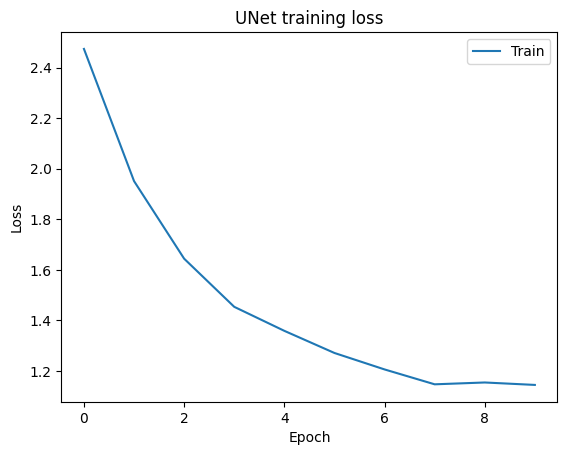

Saved UNet samples to /content/drive/MyDrive/outputs_a2/unet
Saved UNet loss plot to /content/drive/MyDrive/outputs_a2/unet/unet_loss.png


In [25]:
UNET_EPOCHS = CLS_EPOCHS
UNET_LR = 1e-3
UNET_BATCH = 100

unet_train_loader = DataLoader(cls_train, batch_size=UNET_BATCH, shuffle=True)
unet_test_loader = DataLoader(cls_test, batch_size=10, shuffle=False)

unet_model = UNet(num_colours=colours.shape[0], num_filters=32)
unet_history = train_classification(unet_model, unet_train_loader, UNET_EPOCHS, UNET_LR)
unet_loss, unet_acc = eval_classification(unet_model, unet_test_loader)
print(f"UNet validation loss: {unet_loss:.4f} | acc: {unet_acc:.2f}%")

unet_out_dir = os.path.join(OUTPUT_DIR, "unet")
os.makedirs(unet_out_dir, exist_ok=True)

plt.figure()
plt.plot(unet_history, label="Train")
plt.title("UNet training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
unet_plot_path = os.path.join(unet_out_dir, "unet_loss.png")
plt.savefig(unet_plot_path)
plt.show()

grey_batch, cat_batch = next(iter(unet_test_loader))
save_classification_samples(unet_model, grey_batch, cat_batch, colours, unet_out_dir, tag="samples")
print("Saved UNet samples to", unet_out_dir)
print("Saved UNet loss plot to", unet_plot_path)

## Activation summaries

In [26]:
def activation_summary(model, x, layer_map):
    stats = {}
    hooks = []

    def make_hook(name):
        def hook(_, __, output):
            stats[name] = {
                "mean": output.mean().item(),
                "std": output.std().item(),
                "min": output.min().item(),
                "max": output.max().item()
            }
        return hook

    for name, layer in layer_map.items():
        hooks.append(layer.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        model(x.to(device))

    for h in hooks:
        h.remove()

    return stats

sample_grey, _ = next(iter(cls_test_loader))
sample_grey = sample_grey[:4]

cnn_layers = {
    "downconv1": cls_model.downconv1,
    "downconv2": cls_model.downconv2,
    "rfconv": cls_model.rfconv
}

unet_layers = {
    "down1": unet_model.down1,
    "down2": unet_model.down2,
    "bottleneck": unet_model.bottleneck
}

cnn_stats = activation_summary(cls_model, sample_grey, cnn_layers)
unet_stats = activation_summary(unet_model, sample_grey, unet_layers)

print("CNN activation stats:")
for k, v in cnn_stats.items():
    print(k, v)

print("UNet activation stats:")
for k, v in unet_stats.items():
    print(k, v)

CNN activation stats:
downconv1 {'mean': 0.6243802905082703, 'std': 0.7288545370101929, 'min': 0.0, 'max': 6.5648322105407715}
downconv2 {'mean': 0.7065120935440063, 'std': 0.697627604007721, 'min': 0.0, 'max': 5.212099552154541}
rfconv {'mean': 0.4203450381755829, 'std': 0.6081726551055908, 'min': 0.0, 'max': 4.450196266174316}
UNet activation stats:
down1 {'mean': 0.4832908511161804, 'std': 0.6299582719802856, 'min': 0.0, 'max': 6.550277233123779}
down2 {'mean': 0.378248006105423, 'std': 0.6983268857002258, 'min': 0.0, 'max': 5.651585102081299}
bottleneck {'mean': 0.3171178102493286, 'std': 0.5221268534660339, 'min': 0.0, 'max': 5.605193614959717}
